# Embeddings BERT Fine-tuned para Detección de Clickbait

Este notebook realiza:
1. Carga de librerías y datos
2. Fine-tuning de `bert-base-multilingual-cased` (título y cuerpo) — solo si no existe modelo guardado
3. Extracción de embeddings
4. Visualizaciones UMAP

El modelo se entrena como clasificador binario (`num_labels=2`) con la etiqueta `cb` como target. Es decir, los pesos del modelo aprenden a separar el clickbait de no-clickbait. Cuando luego se extrae el embedding `[CLS]`, se está sacando la representación de la red que ha sido optimizada para separarlo. Es por eso que el resultado de que se separe en el UMAP es lo esperable.

Con este análisis no se está demostrando una estructura interna de los datos.

Con este modelo analizo si las representaciones semánticas de BERT capturan la misma estructura que el modelo etiquetador (Taniwa/GPT), y qué características del texto explican esa estructura.

**Flujo del análisis:**
- **Secciones 1–5**: Fine-tuning de BERT con datos del agente GPT + visualización UMAP del espacio semántico
- **Sección 6**: Validación estadística con Mann-Whitney U
- **Sección 7**: Inferencia sobre datos de Taniwa y comparación con clasificaciones de Taniwa
- **Secciones 8–9**: Explicación metodológica y análisis cualitativo de discrepancias


## 0. Configuración — Personaliza aquí los parámetros

In [1]:
# ============================================================
# RUTAS Y NOMBRES — editar aquí para nuevos datasets o modelos
# ============================================================

# Dataset
RUTA_TANIWA = "data_processed/conjunto_noticias_2_limpio.json"
RUTA_DATOS = "data_processed/datos_agente_limpio.json"
# Modelos fine-tuned
MODELO_TITULO_DIR    = "./bert_clickbait_titulo_v2"
MODELO_CONTENIDO_DIR = "./bert_clickbait_contenido_v2"

# Modelo base BERT
MODELO_BASE = "bert-base-multilingual-cased"

# Directorio de salida para gráficas
GRAFICAS_DIR = "img"

# Campos del JSON
CAMPO_TITULO    = "Título"
CAMPO_CONTENIDO = "Contenido"
CAMPO_LABEL     = "cb"          # bool: True = clickbait
CAMPO_PERIODICO = "Periódico"
CAMPO_CATEGORIA = "Categoría"

# Hiperparámetros fine-tuning
MAX_LEN_TITULO    = 128
MAX_LEN_CONTENIDO = 512
BATCH_SIZE        = 16
EPOCHS_TITULO     = 4 #GPT 4
EPOCHS_CONTENIDO  = 4 #GPT 6
LEARNING_RATE     = 2e-5 #GPT 3e-5

# Hiperparámetros UMAP
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1

# Paleta de colores clickbait
COLOR_NO_CLICKBAIT = "#2E86AB"
COLOR_CLICKBAIT    = "#A23B72"

# Paleta de colores periódicos
COLORES_PERIODICOS = {
    "El País":              "#0066CC",
    "El Mundo":             "#FF6600",
    "ABC":                  "#CC0000",
    "La Razón":             "#006633",
    "20 Minutos":           "#0DCE1D",
    "Público":              "#9900CC",
    "eldiario.es":          "#00CCFF",
    "Huffington Post":      "#FF00AA",
    "El Confidencial":      "#CC9900",
    "Mediterráneo Digital": "#009999",
}

# Paleta de colores categorías
COLORES_CATEGORIAS = {
    "Cultura":        "#32F593",
    "Nacional":       "#04696D",
    "Internacional":  "#FF00AA",
}

## 1. Librerías

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoConfig

from umap import UMAP
from matplotlib.patches import Patch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("Librerías cargadas correctamente.")

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779356421.779171    1548 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779356424.242781    1548 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Librerías cargadas correctamente.


## 2. Carga de datos

In [3]:
with open(RUTA_DATOS, "r", encoding="utf-8") as f:
    noticias = json.load(f)

print(f"Noticias cargadas: {len(noticias)}")
print(f"Campos disponibles: {list(noticias[0].keys())}")

Noticias cargadas: 408
Campos disponibles: ['Link', 'Periódico', 'Fecha', 'Título', 'Subtítulo', 'Categoría', 'Contenido', 'cb', 'cb_score', 'cb_label']


## 3. Fine-tuning BERT

Si ya existe el modelo en disco, lo carga directamente. Si no, realiza el entrenamiento y lo guarda.

### 3.1 Funciones de fine-tuning

In [4]:
def preparar_dataset(noticias, campo_texto, campo_label=CAMPO_LABEL, test_size=0.2, seed=42):
    """Crea un HuggingFace Dataset con train/test split."""
    datos = {
        "text":  [n.get(campo_texto, "") for n in noticias],
        "label": [1 if n.get(campo_label) else 0 for n in noticias],
    }
    return Dataset.from_dict(datos).train_test_split(test_size=test_size, seed=seed)


def tokenizar_dataset(datasets, tokenizer, max_length):
    """Tokeniza el dataset completo."""
    def _tokenize(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_length)
    return datasets.map(_tokenize, batched=True)

def calcular_pesos_clase(noticias, campo_label=CAMPO_LABEL):
    """Calcula pesos inversamente proporcionales a la frecuencia de cada clase."""
    labels = [1 if n.get(campo_label) else 0 for n in noticias]
    n_total = len(labels)
    n_cb    = sum(labels)
    n_no_cb = n_total - n_cb

    peso_no_cb = n_total / (2 * n_no_cb)
    peso_cb    = n_total / (2 * n_cb)

    print(f"  No Clickbait: {n_no_cb} muestras → peso {peso_no_cb:.3f}")
    print(f"  Clickbait:    {n_cb} muestras → peso {peso_cb:.3f}")

    return torch.tensor([peso_no_cb, peso_cb], dtype=torch.float)
class TrainerConPesos(Trainer):
    """Trainer personalizado que aplica class weights en el loss."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits

        loss_fn = CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss    = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


def entrenar_modelo(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate):
    """Entrena BERT con class weights para corregir desbalance de clases."""
    print(f"\nEntrenando modelo para campo '{campo_texto}' -> {output_dir}")

    print("\nPesos de clase:")
    class_weights = calcular_pesos_clase(noticias)

    tokenizer    = AutoTokenizer.from_pretrained(MODELO_BASE)
    datasets     = preparar_dataset(noticias, campo_texto)
    datasets_tok = tokenizar_dataset(datasets, tokenizer, max_length)

    config = AutoConfig.from_pretrained(MODELO_BASE, num_labels=2, hidden_dropout_prob=0.25) # GPT 0.2
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODELO_BASE, num_labels=2, ignore_mismatched_sizes=True
    # )
    model  = AutoModelForSequenceClassification.from_pretrained(MODELO_BASE, config=config, ignore_mismatched_sizes=True)

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01, # GPT 0.01
        warmup_ratio=0.1, #GPT 0.1
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_strategy="epoch",
    )
    
    trainer = TrainerConPesos(
        model=model,
        args=training_args,
        train_dataset=datasets_tok["train"],
        eval_dataset=datasets_tok["test"],
        class_weights=class_weights,
    )

    trainer.train()
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Modelo guardado en {output_dir}")


def cargar_o_entrenar(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate):
    """Carga el modelo si ya existe, si no lo entrena."""
    if os.path.isdir(output_dir) and os.listdir(output_dir):
        print(f"Modelo encontrado en '{output_dir}' -> cargando sin entrenar.")
    else:
        entrenar_modelo(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate)

    tokenizer = AutoTokenizer.from_pretrained(output_dir)
    model     = AutoModel.from_pretrained(output_dir)
    model.eval()
    return tokenizer, model


### 3.2 Cargar / entrenar modelo para Títulos

In [5]:
tokenizer_titulo, model_titulo = cargar_o_entrenar(
    noticias,
    campo_texto  = CAMPO_TITULO,
    output_dir   = MODELO_TITULO_DIR,
    max_length   = MAX_LEN_TITULO,
    batch_size   = BATCH_SIZE,
    epochs       = EPOCHS_TITULO,
    learning_rate= LEARNING_RATE,
)

Modelo encontrado en './bert_clickbait_titulo_v2' -> cargando sin entrenar.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1431.08it/s]
[transformers] BertModel LOAD REPORT from: ./bert_clickbait_titulo_v2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 3.3 Cargar / entrenar modelo para Contenido

In [6]:
tokenizer_contenido, model_contenido = cargar_o_entrenar(
    noticias,
    campo_texto  = CAMPO_CONTENIDO,
    output_dir   = MODELO_CONTENIDO_DIR,
    max_length   = MAX_LEN_CONTENIDO,
    batch_size   = BATCH_SIZE // 2,   # batch más pequeño por longitud de texto
    epochs       = EPOCHS_CONTENIDO,
    learning_rate= LEARNING_RATE,
)

Modelo encontrado en './bert_clickbait_contenido_v2' -> cargando sin entrenar.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1328.85it/s]
[transformers] BertModel LOAD REPORT from: ./bert_clickbait_contenido_v2
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 4. Extracción de embeddings

In [7]:
def obtener_embeddings(textos, tokenizer, model, max_length, batch_size=32):
    """
    Extrae el embedding [CLS] para una lista de textos.
    Procesa en batches para no saturar la GPU/CPU.

    Returns
    -------
    np.ndarray  shape (n_textos, hidden_size)
    """
    all_embeddings = []

    for i in range(0, len(textos), batch_size):
        batch = textos[i: i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Batch {i // batch_size + 1}/{len(textos) // batch_size + 1}")

    return np.vstack(all_embeddings)

In [8]:
titulos    = [n.get(CAMPO_TITULO, "")    for n in noticias]
contenidos = [n.get(CAMPO_CONTENIDO, "") for n in noticias]
labels     = [n.get(CAMPO_LABEL, False)  for n in noticias]
periodicos = [n.get(CAMPO_PERIODICO, "") for n in noticias]
categorias = [n.get(CAMPO_CATEGORIA, "") for n in noticias]

print("Extrayendo embeddings de títulos...")
embeddings_titulo = obtener_embeddings(titulos, tokenizer_titulo, model_titulo, MAX_LEN_TITULO)

print("\nExtrayendo embeddings de contenido...")
embeddings_contenido = obtener_embeddings(contenidos, tokenizer_contenido, model_contenido, MAX_LEN_CONTENIDO)

print(f"\nShape títulos:   {embeddings_titulo.shape}")
print(f"Shape contenido: {embeddings_contenido.shape}")

Extrayendo embeddings de títulos...
  Batch 10/13

Extrayendo embeddings de contenido...
  Batch 10/13

Shape títulos:   (408, 768)
Shape contenido: (408, 768)


## 5. Reducción UMAP y visualizaciones

Las funciones de graficado reciben los embeddings y metadatos como parámetros, por lo que son fácilmente reutilizables con nuevos datos.

### 5.1 Funciones de visualización

In [9]:
def reducir_umap(embeddings, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=42):
    """Reduce embeddings a 2D con UMAP."""
    reducer = UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    return reducer.fit_transform(embeddings)


def _asignar_colores_faltantes(elementos, paleta):
    """Añade colores aleatorios a la paleta para elementos no definidos."""
    for elem in set(elementos):
        if elem not in paleta:
            paleta[elem] = f"#{np.random.randint(0, 0xFFFFFF):06x}"
    return paleta


def graficar_umap_clickbait(embeddings_2d, labels, titulo_grafica, guardar_como=None):
    """
    Jointplot UMAP coloreado por Clickbait / No Clickbait.

    Parámetros
    ----------
    embeddings_2d   : np.ndarray (N, 2)
    labels          : list[bool]  — True = clickbait
    titulo_grafica  : str
    guardar_como    : str|None    — ruta de guardado, ej. "img/titulo_clickbait.png"
    """
    df = pd.DataFrame({
        "UMAP 1":   embeddings_2d[:, 0],
        "UMAP 2":   embeddings_2d[:, 1],
        "Clickbait": ["Clickbait" if x else "No Clickbait" for x in labels],
    })

    sns.set_style("whitegrid")
    palette = {"No Clickbait": COLOR_NO_CLICKBAIT, "Clickbait": COLOR_CLICKBAIT}

    g = sns.jointplot(
        data=df, x="UMAP 1", y="UMAP 2",
        hue="Clickbait", kind="scatter",
        alpha=0.55, palette=palette,
        height=10, space=0.15, s=50,
        marginal_kws=dict(fill=True, common_norm=False, alpha=0.4),
    )

    g.fig.suptitle(titulo_grafica, fontsize=16, fontweight="bold", y=0.995)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=12, fontweight="bold")
    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()

def graficar_umap_periodico(embeddings_2d, periodicos, labels, titulo_grafica, guardar_como=None):
    """
    JointGrid UMAP con KDE de periódico de fondo y scatter coloreado por periódico.

    Parámetros
    ----------
    embeddings_2d : np.ndarray (N, 2)
    periodicos    : list[str]
    labels        : list[bool]   — True = clickbait (para el contorno KDE de fondo)
    titulo_grafica: str
    guardar_como  : str|None
    """
    paleta = _asignar_colores_faltantes(periodicos, dict(COLORES_PERIODICOS))
    palette_cb = {"No Clickbait": COLOR_NO_CLICKBAIT, "Clickbait": COLOR_CLICKBAIT}

    df = pd.DataFrame({
        "UMAP 1":    embeddings_2d[:, 0],
        "UMAP 2":    embeddings_2d[:, 1],
        "Periodico": periodicos,
        "Clickbait": ["Clickbait" if x else "No Clickbait" for x in labels],
    })

    sns.set_style("whitegrid")
    g = sns.JointGrid(data=df, x="UMAP 1", y="UMAP 2", height=10, space=0.15)

    # KDE de fondo por clickbait (igual que en graficar_umap_categoria)
    for cb, color in palette_cb.items():
        subset = df[df["Clickbait"] == cb]
        sns.kdeplot(data=subset, x="UMAP 1", y="UMAP 2",
                    fill=True, alpha=0.5, levels=3, color=color, ax=g.ax_joint)

    # Scatter por periódico encima
    for periodico in df["Periodico"].unique():
        subset = df[df["Periodico"] == periodico]
        g.ax_joint.scatter(
            subset["UMAP 1"], subset["UMAP 2"],
            label=periodico, alpha=0.75, s=50,
            color=paleta[periodico], edgecolors="black", linewidth=0.4,
        )

    # Marginales por periódico
    for periodico in df["Periodico"].unique():
        subset = df[df["Periodico"] == periodico]
        sns.kdeplot(data=subset, x="UMAP 1", fill=True, alpha=0.35,
                    color=paleta[periodico], ax=g.ax_marg_x)
        sns.kdeplot(data=subset, y="UMAP 2", fill=True, alpha=0.35,
                    color=paleta[periodico], ax=g.ax_marg_y)

    g.fig.suptitle(titulo_grafica, fontsize=18, fontweight="bold", y=1.02)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=13, fontweight="bold")

    # Leyenda periódicos
    legend_per = g.ax_joint.legend(
        title="Periódico", fontsize=10, title_fontsize=11, loc="upper right", frameon=True
    )
    g.ax_joint.add_artist(legend_per)

    # Leyenda clickbait
    handles_cb = [
        Patch(facecolor=COLOR_NO_CLICKBAIT, edgecolor="none", alpha=0.8, label="No Clickbait"),
        Patch(facecolor=COLOR_CLICKBAIT,    edgecolor="none", alpha=0.8, label="Clickbait"),
    ]
    g.ax_joint.legend(handles=handles_cb, title="Clickbait", fontsize=10,
                      title_fontsize=11, loc="upper left", frameon=True)

    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    sns.despine()
    plt.tight_layout()

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()


def graficar_umap_categoria(embeddings_2d, labels, categorias, titulo_grafica, guardar_como=None):
    """
    JointGrid UMAP con KDE de clickbait de fondo y scatter por categoría.

    Parámetros
    ----------
    embeddings_2d : np.ndarray (N, 2)
    labels        : list[bool]   — True = clickbait
    categorias    : list[str]
    titulo_grafica: str
    guardar_como  : str|None
    """
    paleta_cat = _asignar_colores_faltantes(categorias, dict(COLORES_CATEGORIAS))
    palette_cb = {"No Clickbait": COLOR_NO_CLICKBAIT, "Clickbait": COLOR_CLICKBAIT}

    df = pd.DataFrame({
        "UMAP 1":    embeddings_2d[:, 0],
        "UMAP 2":    embeddings_2d[:, 1],
        "Clickbait": ["Clickbait" if x else "No Clickbait" for x in labels],
        "Categoría": categorias,
    })

    sns.set_style("whitegrid")
    g = sns.JointGrid(data=df, x="UMAP 1", y="UMAP 2", height=10, space=0.15)

    # KDE de fondo por clickbait
    for cb, color in palette_cb.items():
        subset = df[df["Clickbait"] == cb]
        sns.kdeplot(data=subset, x="UMAP 1", y="UMAP 2",
                    fill=True, alpha=0.5, levels=3, color=color, ax=g.ax_joint)

    # Scatter por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        g.ax_joint.scatter(
            subset["UMAP 1"], subset["UMAP 2"],
            label=cat, alpha=0.75, s=50,
            color=paleta_cat[cat], edgecolors="black", linewidth=0.4,
        )

    # Marginales por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        sns.kdeplot(data=subset, x="UMAP 1", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_x)
        sns.kdeplot(data=subset, y="UMAP 2", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_y)

    g.fig.suptitle(titulo_grafica, fontsize=18, fontweight="bold", y=1.02)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=13, fontweight="bold")

    legend_cat = g.ax_joint.legend(
        title="Categoría", fontsize=10, title_fontsize=11, loc="upper right", frameon=True
    )
    g.ax_joint.add_artist(legend_cat)

    handles_cb = [
        Patch(facecolor=COLOR_NO_CLICKBAIT, edgecolor="none", alpha=0.8, label="No Clickbait"),
        Patch(facecolor=COLOR_CLICKBAIT,    edgecolor="none", alpha=0.8, label="Clickbait"),
    ]
    g.ax_joint.legend(handles=handles_cb, title="Clickbait", fontsize=10,
                      title_fontsize=11, loc="upper left", frameon=True)

    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    sns.despine()
    plt.tight_layout()

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()

### 5.2 Reducción UMAP

In [10]:
print("Calculando UMAP para títulos...")
umap_titulo = reducir_umap(embeddings_titulo)

print("Calculando UMAP para contenido...")
umap_contenido = reducir_umap(embeddings_contenido)

print("UMAP completado.")

Calculando UMAP para títulos...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculando UMAP para contenido...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completado.


### 5.3 Espacios Embebidos de Títulos — Análisis UMAP

Guardado: img/UMAP_titulos_clickbait_taniwa.png


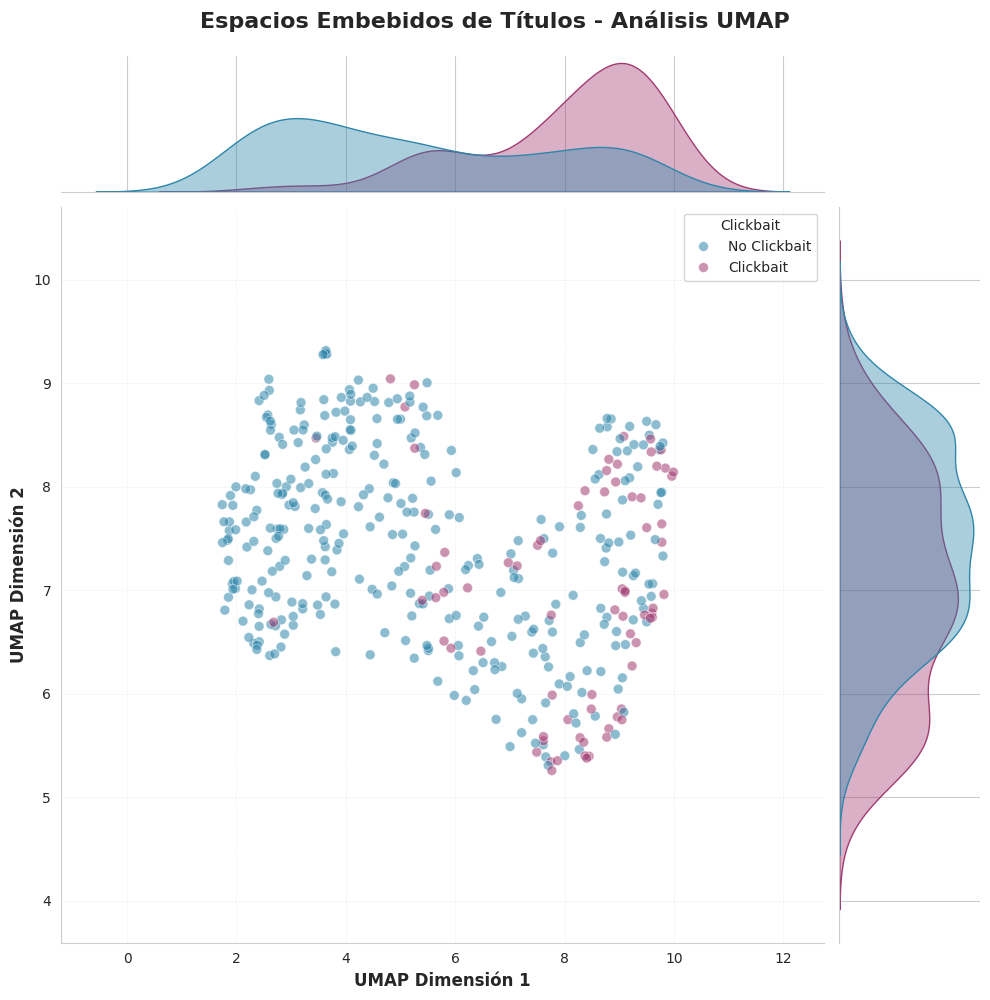

In [11]:
graficar_umap_clickbait(
    umap_titulo,
    labels,
    titulo_grafica="Espacios Embebidos de Títulos - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_clickbait_taniwa.png",
)

### 5.4 Espacios Embebidos de Contenido — Análisis UMAP

Guardado: img/UMAP_contenido_clickbait_taniwa.png


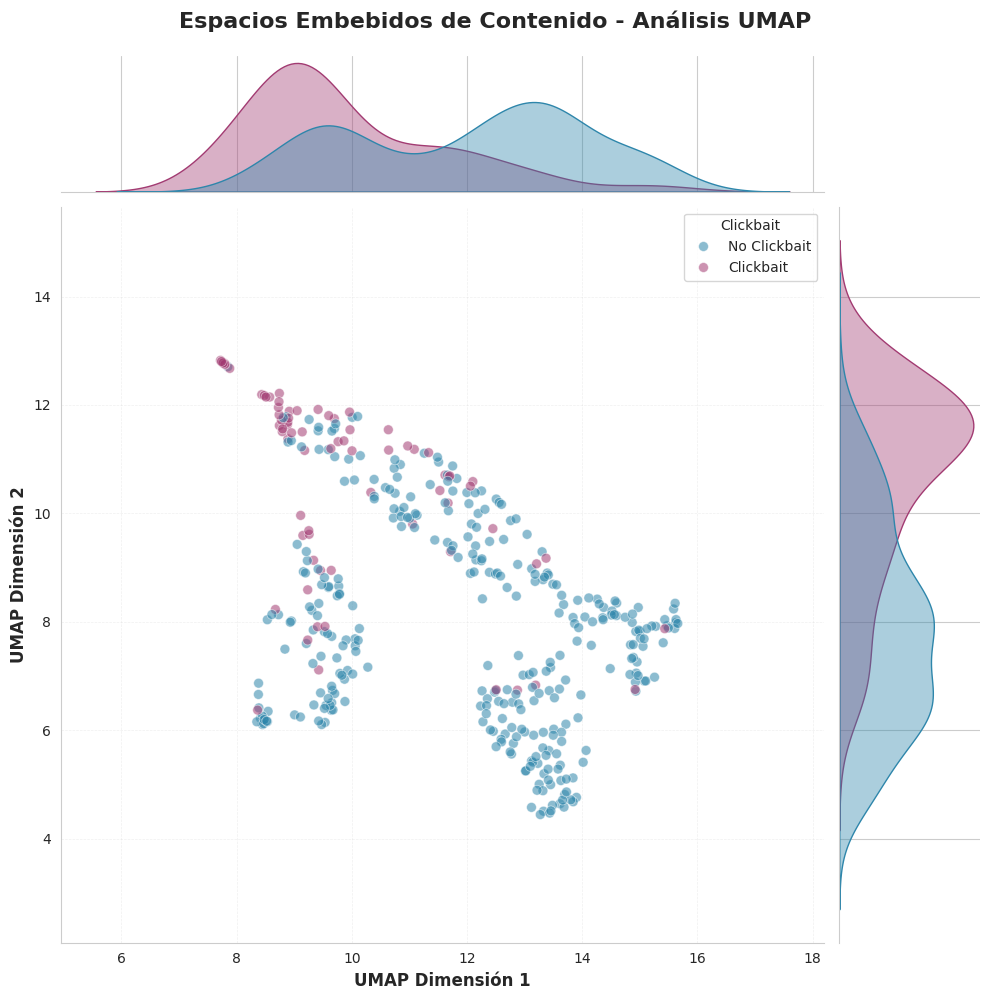

In [12]:
graficar_umap_clickbait(
    umap_contenido,
    labels,
    titulo_grafica="Espacios Embebidos de Contenido - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_clickbait_taniwa.png",
)

### 5.5 Espacios Embebidos de Contenido por Periódico — Análisis UMAP

Guardado: img/UMAP_contenido_periodico_taniwa.png


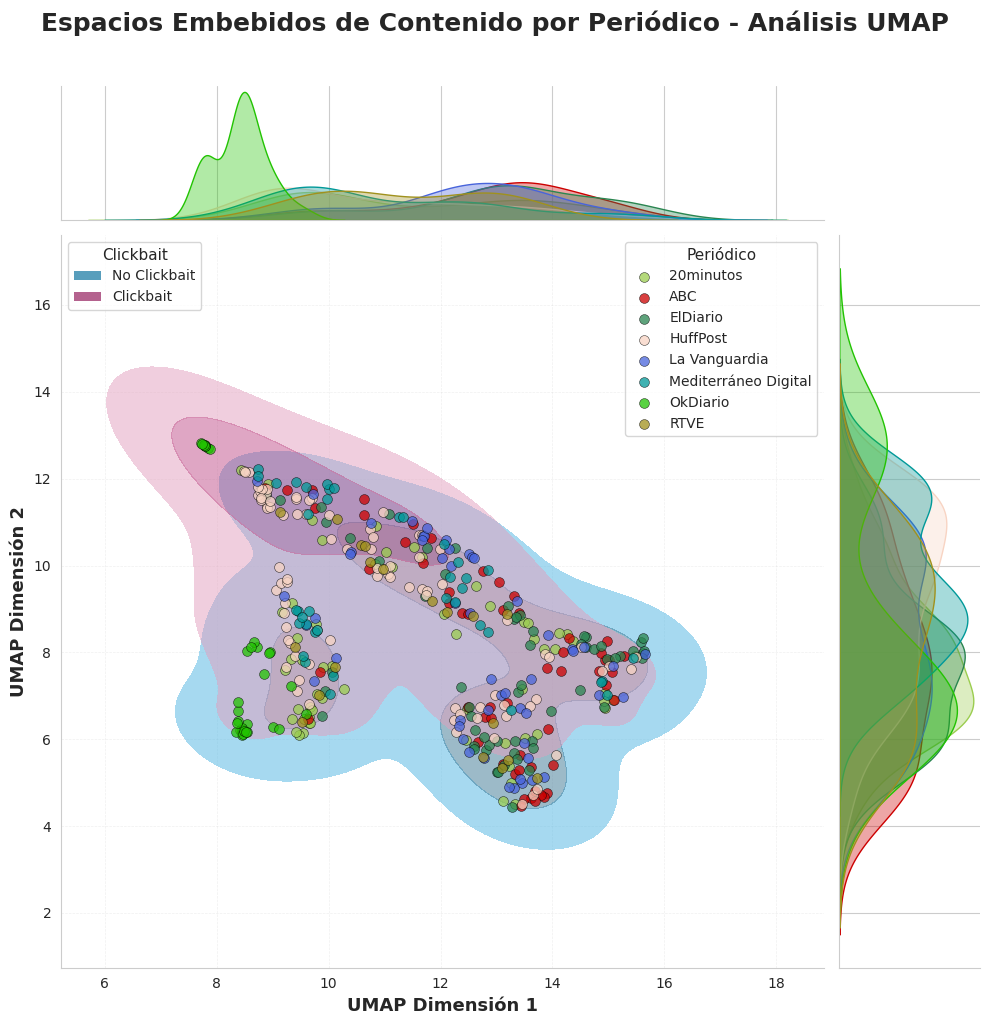

In [13]:
graficar_umap_periodico(
    umap_contenido, periodicos, labels,
    titulo_grafica="Espacios Embebidos de Contenido por Periódico - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_periodico_taniwa.png",
)

### 5.6 Espacios Embebidos de Títulos por Periódico — Análisis UMAP

Guardado: img/UMAP_titulos_periodico_taniwa.png


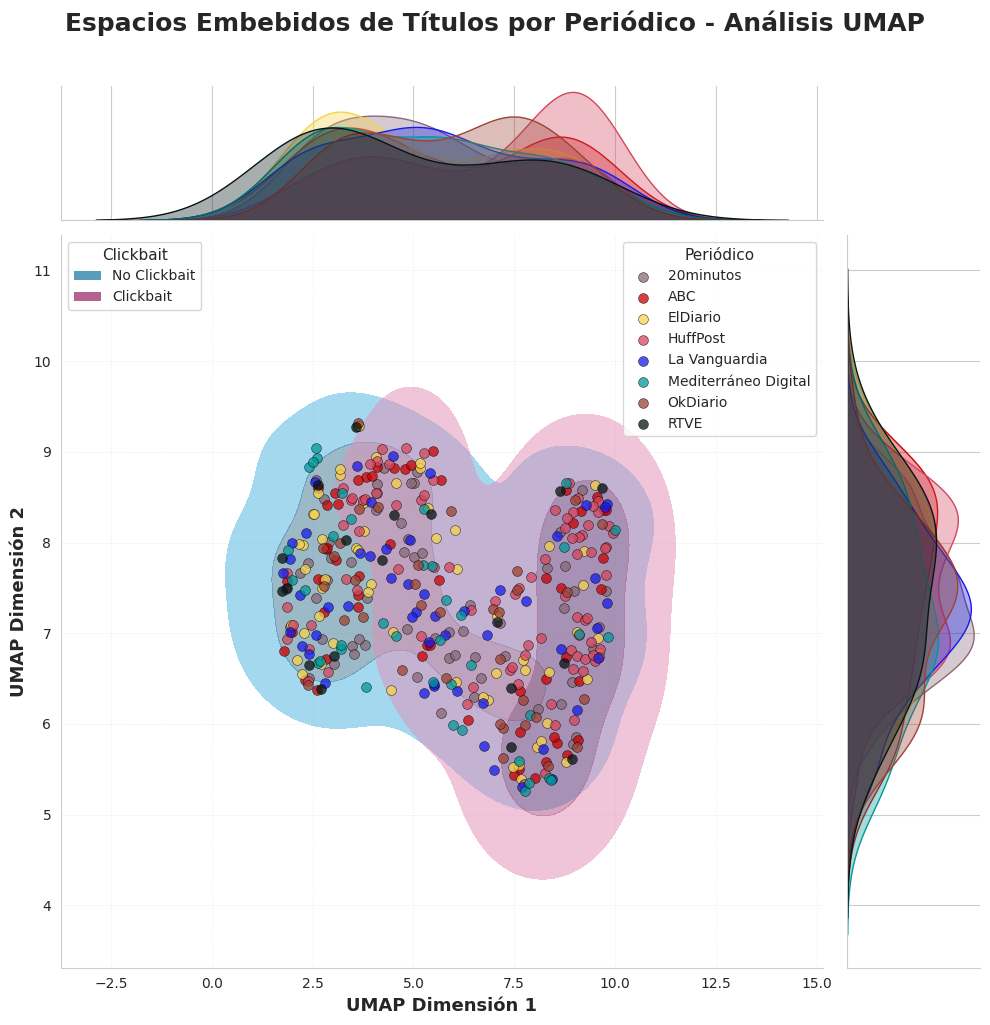

In [14]:
graficar_umap_periodico(
    umap_titulo, periodicos, labels,
    titulo_grafica="Espacios Embebidos de Títulos por Periódico - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_periodico_taniwa.png",
)

### 5.7 Espacios Embebidos de Títulos — UMAP (KDE + categoría)

Guardado: img/UMAP_titulos_categoria_taniwa.png


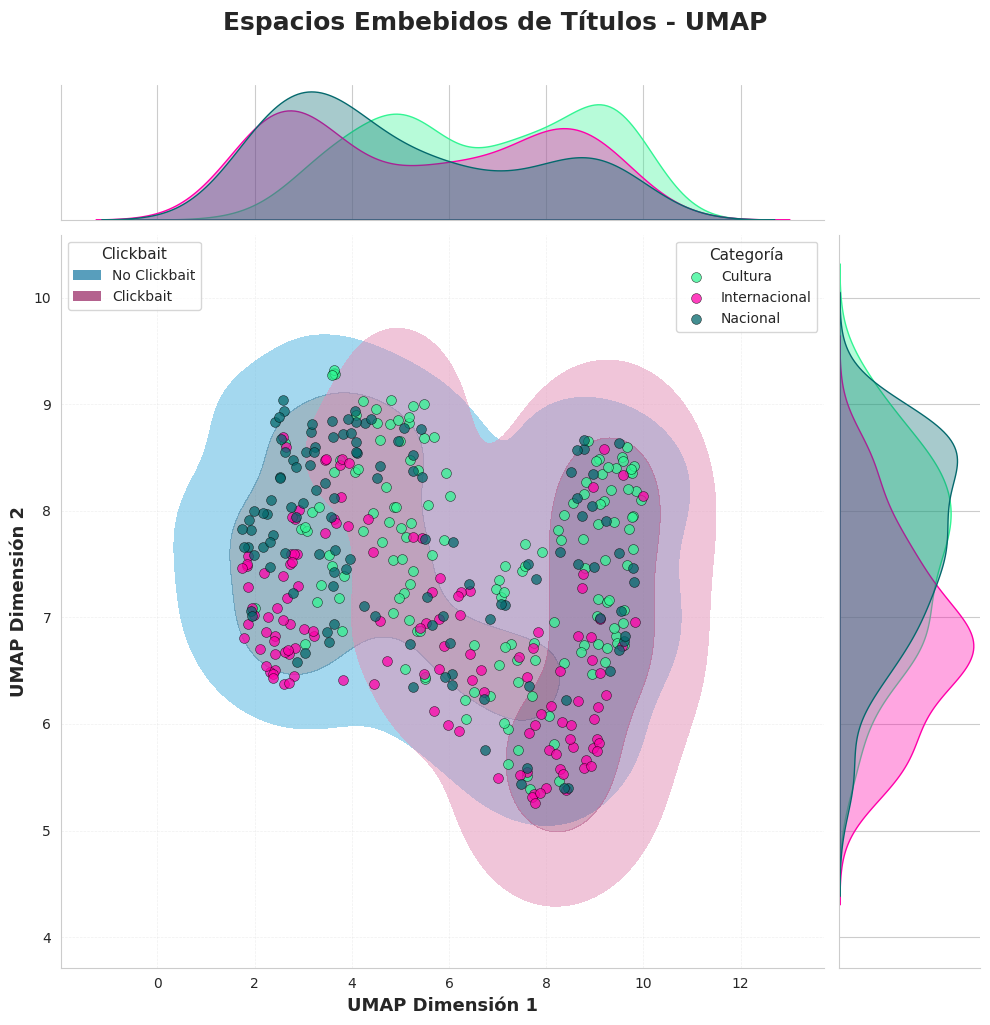

In [15]:
graficar_umap_categoria(
    umap_titulo,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Títulos - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_categoria_taniwa.png",
)

### 5.8 Espacios Embebidos de Contenido — UMAP (KDE + categoría)

Guardado: img/UMAP_contenido_categoria_taniwa.png


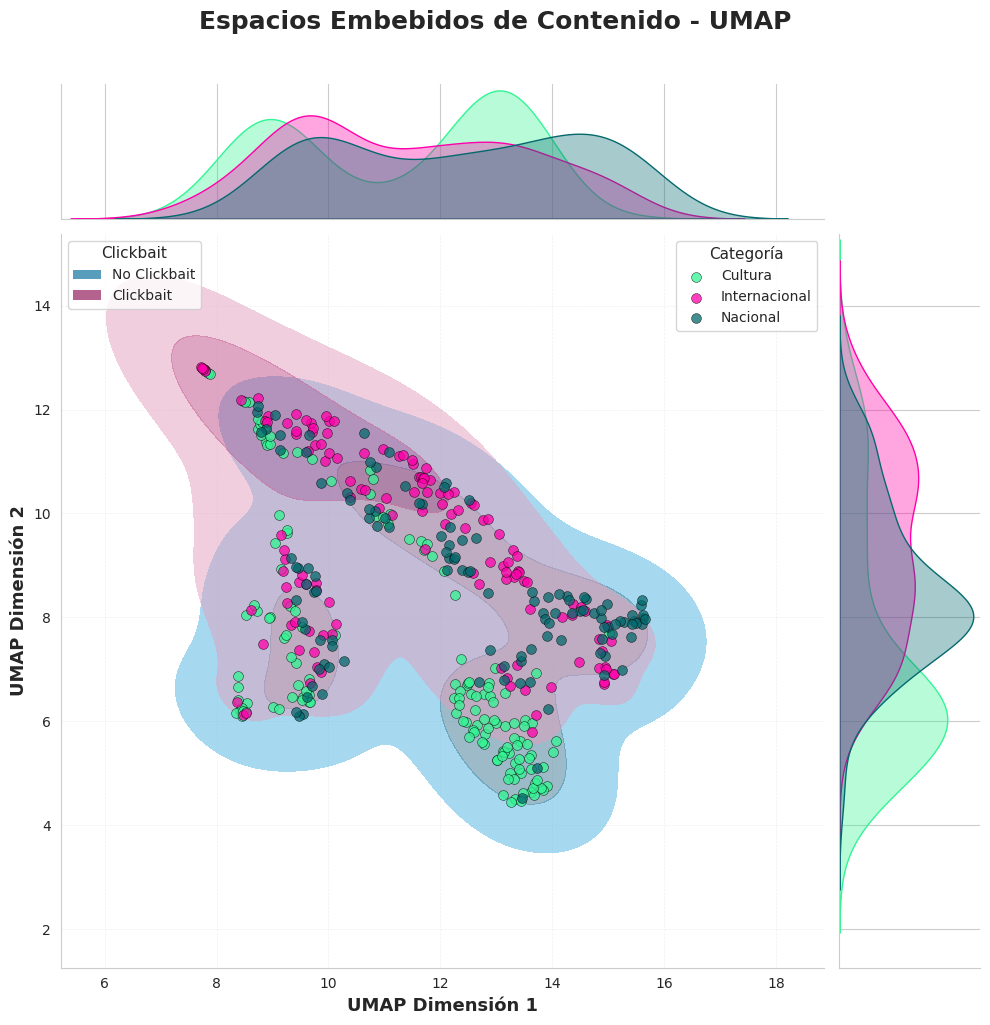

In [16]:
graficar_umap_categoria(
    umap_contenido,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Contenido - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_categoria_taniwa.png",
)

## 6. Análisis estadístico — Mann-Whitney U


Comprueba si las distribuciones de embeddings (proyectados a 2D por UMAP) son 
estadísticamente distintas entre grupos. Usamos Mann-Whitney porque no asume 
normalidad y funciona bien con embeddings de alta dimensión proyectados.

Se aplica por separado sobre UMAP 1 y UMAP 2. Si ambas coordenadas son 
significativas, la separación visual no es un artefacto.

In [17]:
from scipy.stats import mannwhitneyu
from itertools import combinations

ALPHA = 0.05  # nivel de significancia — ajustable en Sección 0

def mann_whitney_grupos(umap_2d, grupos, nombre_grupo, nombre_embedding, alpha=ALPHA):
    """
    Aplica Mann-Whitney U entre todos los pares de grupos sobre las dos
    coordenadas UMAP. Muestra tabla de resultados con corrección de
    Bonferroni para comparaciones múltiples.

    Parámetros
    ----------
    umap_2d          : np.ndarray (N, 2)
    grupos           : list[str|bool]  — etiqueta de grupo para cada punto
    nombre_grupo     : str             — ej. "Clickbait", "Periódico", "Categoría"
    nombre_embedding : str             — ej. "Títulos", "Contenido"
    alpha            : float           — nivel de significancia base
    """
    df = pd.DataFrame({
        "UMAP 1": umap_2d[:, 0],
        "UMAP 2": umap_2d[:, 1],
        "grupo":  [str(g) for g in grupos],
    })

    grupos_unicos = sorted(df["grupo"].unique())
    pares = list(combinations(grupos_unicos, 2))
    alpha_corregido = alpha / len(pares)  # Bonferroni

    print(f"\n{'='*70}")
    print(f"  Mann-Whitney U — {nombre_grupo} | Embeddings: {nombre_embedding}")
    print(f"  Comparaciones: {len(pares)} | alpha corregido (Bonferroni): {alpha_corregido:.4f}")
    print(f"{'='*70}")
    print(f"  {'Par':<35} {'UMAP1 p-val':>12} {'UMAP2 p-val':>12} {'Significativo':>14}")
    print(f"  {'-'*70}")

    resultados = []
    for g1, g2 in pares:
        x1 = df[df["grupo"] == g1]["UMAP 1"].values
        x2 = df[df["grupo"] == g2]["UMAP 1"].values
        y1 = df[df["grupo"] == g1]["UMAP 2"].values
        y2 = df[df["grupo"] == g2]["UMAP 2"].values

        _, p1 = mannwhitneyu(x1, x2, alternative="two-sided")
        _, p2 = mannwhitneyu(y1, y2, alternative="two-sided")

        sig = p1 < alpha_corregido and p2 < alpha_corregido
        etiqueta = "✅ Sí" if sig else "❌ No"
        par_str = f"{g1} vs {g2}"

        print(f"  {par_str:<35} {p1:>12.4f} {p2:>12.4f} {etiqueta:>14}")
        resultados.append({"par": par_str, "p_umap1": p1, "p_umap2": p2, "significativo": sig})

    n_sig = sum(r["significativo"] for r in resultados)
    print(f"\n  Pares significativos: {n_sig}/{len(pares)}")
    return pd.DataFrame(resultados)


# --- Clickbait vs No Clickbait ---
labels_str = ["Clickbait" if x else "No Clickbait" for x in labels]

resultados_cb_titulo   = mann_whitney_grupos(umap_titulo,   labels_str, "Clickbait", "Títulos")
resultados_cb_contenido = mann_whitney_grupos(umap_contenido, labels_str, "Clickbait", "Contenido")

# --- Por periódico ---
resultados_per_titulo   = mann_whitney_grupos(umap_titulo,   periodicos, "Periódico", "Títulos")
resultados_per_contenido = mann_whitney_grupos(umap_contenido, periodicos, "Periódico", "Contenido")

# --- Por categoría ---
resultados_cat_titulo   = mann_whitney_grupos(umap_titulo,   categorias, "Categoría", "Títulos")
resultados_cat_contenido = mann_whitney_grupos(umap_contenido, categorias, "Categoría", "Contenido")


  Mann-Whitney U — Clickbait | Embeddings: Títulos
  Comparaciones: 1 | alpha corregido (Bonferroni): 0.0500
  Par                                  UMAP1 p-val  UMAP2 p-val  Significativo
  ----------------------------------------------------------------------
  Clickbait vs No Clickbait                 0.0000       0.0007           ✅ Sí

  Pares significativos: 1/1

  Mann-Whitney U — Clickbait | Embeddings: Contenido
  Comparaciones: 1 | alpha corregido (Bonferroni): 0.0500
  Par                                  UMAP1 p-val  UMAP2 p-val  Significativo
  ----------------------------------------------------------------------
  Clickbait vs No Clickbait                 0.0000       0.0000           ✅ Sí

  Pares significativos: 1/1

  Mann-Whitney U — Periódico | Embeddings: Títulos
  Comparaciones: 28 | alpha corregido (Bonferroni): 0.0018
  Par                                  UMAP1 p-val  UMAP2 p-val  Significativo
  ------------------------------------------------------------------

El test se aplica sobre las coordenadas UMAP 1 y UMAP 2 por separado, y se considera que la separación es significativa solo si ambas lo son. Para periódicos y categorías hay muchos pares, por eso se aplica corrección de Bonferroni automáticamente, sin ella casi todo sale significativo por azar. 

## 7. Comparación BERT (entrenado con GPT) vs Taniwa

El modelo BERT se entrenó con las clasificaciones del agente GPT. Aquí se pasa el corpus de Taniwa (noticias distintas, etiquetadas por Taniwa) por ese modelo para ver en qué medida BERT replicaría las decisiones de Taniwa.

Es una evaluación de **transferencia cruzada**: ¿captura BERT (entrenado con GPT) el mismo concepto de clickbait que Taniwa? El Kappa mide el acuerdo corregido por azar entre ambos.

**Estructura:**
1. Carga de datos de Taniwa
2. Clasificación con BERT
3. Acuerdo global (Cohen's Kappa)
4. UMAP coloreado por acuerdo/desacuerdo
5. Discrepancias por periódico y categoría
6. Resumen final


### 7.1 Configuración específica del agente

In [18]:
# Ruta al JSON limpio del agente — ajustar si cambia

# Colores para el mapa de acuerdo
COLOR_ACUERDO_CB    = "#068801"   # ambos dicen clickbait
COLOR_ACUERDO_NO_CB = "#005CB3"   # ambos dicen no clickbait
COLOR_SOLO_BERT     = "#9C02AA"   # solo BERT dice clickbait
COLOR_SOLO_GPT      = "#A80E0E"   # solo GPT dice clickbait


### 7.2 Carga de datos del agente

In [19]:
with open(RUTA_TANIWA, "r", encoding="utf-8") as f:
    noticias_agente = json.load(f)

titulos_agente    = [n.get(CAMPO_TITULO, "")    for n in noticias_agente]
contenidos_agente = [n.get(CAMPO_CONTENIDO, "") for n in noticias_agente]
labels_taniwa       = [bool(n.get("cb", False))   for n in noticias_agente]
periodicos_agente = [n.get(CAMPO_PERIODICO, "") for n in noticias_agente]
categorias_agente = [n.get(CAMPO_CATEGORIA, "") for n in noticias_agente]

print(f"Noticias del agente: {len(noticias_agente)}")
print(f"Clickbait (TANIWA):    {sum(labels_taniwa)}")
print(f"No Clickbait (TANIWA): {len(labels_taniwa) - sum(labels_taniwa)}")
print(f"Periodicos: {sorted(set(periodicos_agente))}")


Noticias del agente: 540
Clickbait (TANIWA):    131
No Clickbait (TANIWA): 409
Periodicos: ['20minutos', 'ABC', 'El Confidencial', 'ElDiario', 'Huffingtonpost', 'La Vanguardia', 'Mediterráneo Digital', 'RTVE', 'okdiario']


### 7.3 Clasificación con BERT (Taniwa)

Se usa el modelo de clasificación guardado (no el de embeddings) para predecir
sobre las noticias del agente. Estos datos nunca fueron vistos durante el entrenamiento.

In [20]:
import torch.nn.functional as F

def clasificar_con_bert(textos, tokenizer, model_dir, max_length, batch_size=16):
    """
    Clasifica textos con el modelo de clasificacion BERT guardado en model_dir.
    Devuelve:
      - labels_bert : list[bool]   prediccion binaria
      - scores_bert : list[float]  probabilidad de clase clickbait
    """
    clf = AutoModelForSequenceClassification.from_pretrained(model_dir)
    clf.eval()
    all_labels, all_scores = [], []

    for i in range(0, len(textos), batch_size):
        batch  = textos[i: i + batch_size]
        inputs = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        )
        with torch.no_grad():
            logits = clf(**inputs).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_labels.extend(probs.argmax(axis=1).tolist())
        all_scores.extend(probs[:, 1].tolist())

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Batch {i // batch_size + 1}/{len(textos) // batch_size + 1}")

    return [bool(l) for l in all_labels], all_scores


print("Clasificando titulos con BERT...")
labels_bert_titulo, scores_bert_titulo = clasificar_con_bert(
    titulos_agente, tokenizer_titulo, MODELO_TITULO_DIR, MAX_LEN_TITULO
)

print("\nClasificando contenido con BERT...")
labels_bert_contenido, scores_bert_contenido = clasificar_con_bert(
    contenidos_agente, tokenizer_contenido, MODELO_CONTENIDO_DIR, MAX_LEN_CONTENIDO
)

print(f"\nClickbait BERT (titulo):   {sum(labels_bert_titulo)}")
print(f"Clickbait BERT (contenido): {sum(labels_bert_contenido)}")


Clasificando titulos con BERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1936.88it/s]


  Batch 10/34
  Batch 20/34
  Batch 30/34

Clasificando contenido con BERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1513.81it/s]


  Batch 10/34
  Batch 20/34
  Batch 30/34

Clickbait BERT (titulo):   80
Clickbait BERT (contenido): 129


### 7.4 Acuerdo global — Cohen's Kappa

Rango de Kappa: **< 0.2** pobre | **0.2–0.4** leve | **0.4–0.6** moderado | **0.6–0.8** sustancial | **> 0.8** casi perfecto

In [21]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix

def resumen_acuerdo(labels_gpt, labels_bert, nombre):
    """Muestra metricas de acuerdo entre GPT y BERT para un campo."""
    y_gpt  = np.array([1 if x else 0 for x in labels_gpt])
    y_bert = np.array([1 if x else 0 for x in labels_bert])

    kappa   = cohen_kappa_score(y_gpt, y_bert)
    acuerdo = np.mean(y_gpt == y_bert)
    cm      = confusion_matrix(y_gpt, y_bert)

    nivel = ("casi perfecto" if kappa > 0.8 else
             "sustancial"   if kappa > 0.6 else
             "moderado"     if kappa > 0.4 else
             "leve"         if kappa > 0.2 else "pobre")

    print(f"\n{'='*55}")
    print(f"  Acuerdo TANIWA vs BERT -- {nombre}")
    print(f"{'='*55}")
    print(f"  Acuerdo simple : {acuerdo:.3f} ({acuerdo*100:.1f}%)")
    print(f"  Cohen's Kappa  : {kappa:.3f}  -> {nivel}")
    print(f"\n  Matriz de confusion (filas=TANIWA, cols=BERT):")
    print(f"                 BERT No CB   BERT CB")
    print(f"  TANIWA No CB   {cm[0,0]:>10}  {cm[0,1]:>8}")
    print(f"  TANIWA CB      {cm[1,0]:>10}  {cm[1,1]:>8}")
    return kappa, acuerdo, cm


kappa_titulo,    acuerdo_titulo,    cm_titulo    = resumen_acuerdo(labels_taniwa, labels_bert_titulo,    "Titulos")
kappa_contenido, acuerdo_contenido, cm_contenido = resumen_acuerdo(labels_taniwa, labels_bert_contenido, "Contenido")



  Acuerdo TANIWA vs BERT -- Titulos
  Acuerdo simple : 0.820 (82.0%)
  Cohen's Kappa  : 0.437  -> moderado

  Matriz de confusion (filas=TANIWA, cols=BERT):
                 BERT No CB   BERT CB
  TANIWA No CB          386        23
  TANIWA CB              74        57

  Acuerdo TANIWA vs BERT -- Contenido
  Acuerdo simple : 0.626 (62.6%)
  Cohen's Kappa  : -0.023  -> pobre

  Matriz de confusion (filas=TANIWA, cols=BERT):
                 BERT No CB   BERT CB
  TANIWA No CB          309       100
  TANIWA CB             102        29


### 7.5 Embeddings y UMAP de las noticias del agente

In [22]:
print("Extrayendo embeddings de titulos (agente)...")
emb_agente_titulo = obtener_embeddings(
    titulos_agente, tokenizer_titulo, model_titulo, MAX_LEN_TITULO
)

print("\nExtrayendo embeddings de contenido (agente)...")
emb_agente_contenido = obtener_embeddings(
    contenidos_agente, tokenizer_contenido, model_contenido, MAX_LEN_CONTENIDO
)

print("\nCalculando UMAP para titulos (agente)...")
umap_agente_titulo = reducir_umap(emb_agente_titulo)

print("Calculando UMAP para contenido (agente)...")
umap_agente_contenido = reducir_umap(emb_agente_contenido)

print("Completado.")


Extrayendo embeddings de titulos (agente)...
  Batch 10/17

Extrayendo embeddings de contenido (agente)...
  Batch 10/17

Calculando UMAP para titulos (agente)...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculando UMAP para contenido (agente)...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Completado.


### 7.6 UMAP coloreado por acuerdo BERT vs GPT

Cada punto es una noticia del agente. El color indica si ambos modelos coinciden
y, cuando no, quién dice clickbait.

In [23]:
def etiqueta_acuerdo(gpt, bert):
    if gpt and bert:         return "Ambos: Clickbait"
    if not gpt and not bert: return "Ambos: No Clickbait"
    if bert and not gpt:     return "Solo BERT: Clickbait"
    return "Solo Taniwa: Clickbait"


def graficar_umap_acuerdo(embeddings_2d, labels_gpt, labels_bert, titulo_grafica, guardar_como=None):
    """
    Jointplot UMAP coloreado por categoria de acuerdo entre GPT y BERT.
    El pie de la figura muestra N y % de cada categoria.
    """
    palette_acuerdo = {
        "Ambos: Clickbait":     COLOR_ACUERDO_CB,
        "Ambos: No Clickbait":  COLOR_ACUERDO_NO_CB,
        "Solo BERT: Clickbait": COLOR_SOLO_BERT,
        "Solo Taniwa: Clickbait":  COLOR_SOLO_GPT,
    }
    acuerdo = [etiqueta_acuerdo(g, b) for g, b in zip(labels_gpt, labels_bert)]
    total   = len(acuerdo)
    df = pd.DataFrame({"UMAP 1": embeddings_2d[:, 0], "UMAP 2": embeddings_2d[:, 1], "Acuerdo": acuerdo})

    sns.set_style("whitegrid")
    g = sns.jointplot(
        data=df, x="UMAP 1", y="UMAP 2",
        hue="Acuerdo", kind="scatter",
        alpha=0.65, palette=palette_acuerdo,
        height=10, space=0.15, s=55,
        marginal_kws=dict(fill=True, common_norm=False, alpha=0.4),
    )
    g.fig.suptitle(titulo_grafica, fontsize=16, fontweight="bold", y=0.995)
    g.set_axis_labels("UMAP Dimension 1", "UMAP Dimension 2", fontsize=12, fontweight="bold")
    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

    # Pie de figura con N y % por categoria
    conteo = pd.Series(acuerdo).value_counts()
    partes = []
    for k in palette_acuerdo:
        n   = conteo.get(k, 0)
        pct = n / total * 100
        partes.append(f"{k}: {n} ({pct:.1f}%)")
    nota = "  |  ".join(partes)
    g.fig.text(0.5, 0.005, nota, ha="center", fontsize=8.5, color="gray")

    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()


### 7.7 UMAP acuerdo — Títulos

Guardado: img/agente_acuerdo_titulo.png


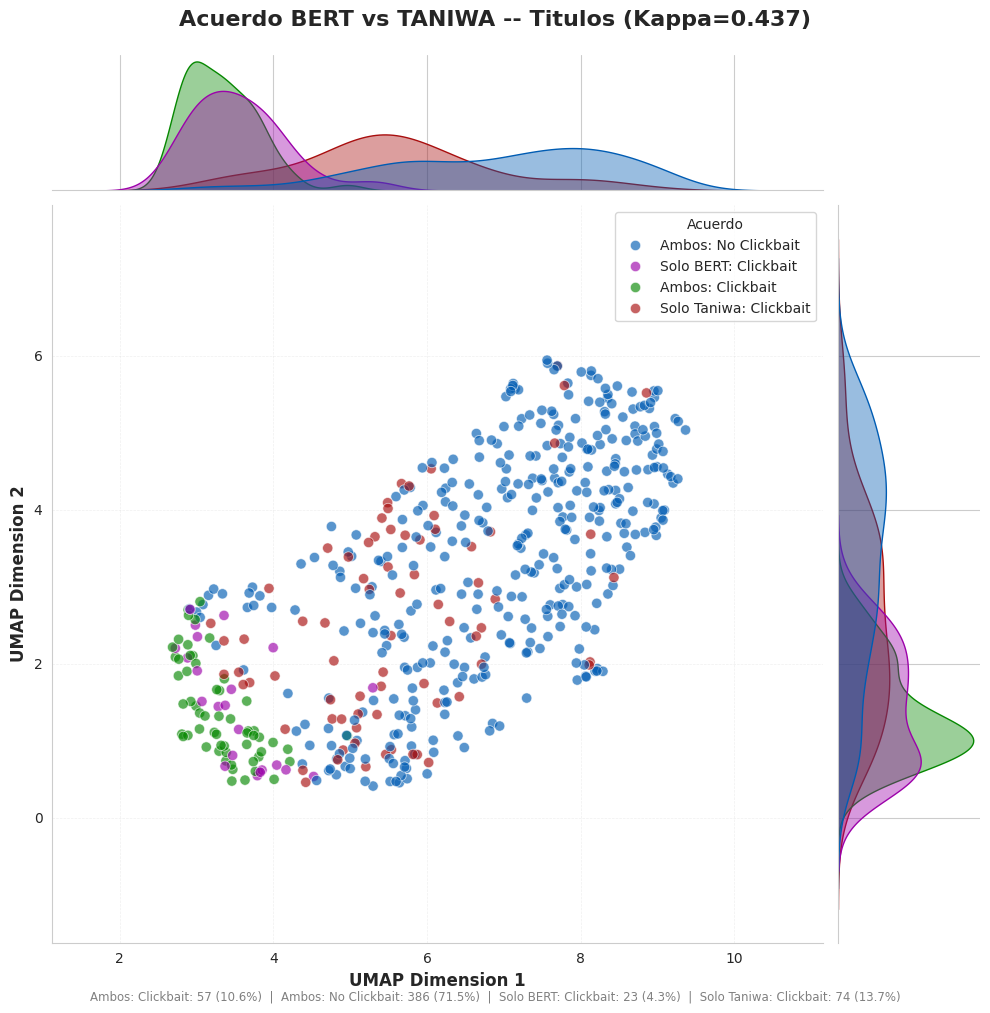

In [24]:
graficar_umap_acuerdo(
    umap_agente_titulo, labels_taniwa, labels_bert_titulo,
    titulo_grafica=f"Acuerdo BERT vs TANIWA -- Titulos (Kappa={kappa_titulo:.3f})",
    guardar_como=f"{GRAFICAS_DIR}/agente_acuerdo_titulo.png",
)


### 7.8 UMAP acuerdo — Contenido

Guardado: img/agente_acuerdo_contenido.png


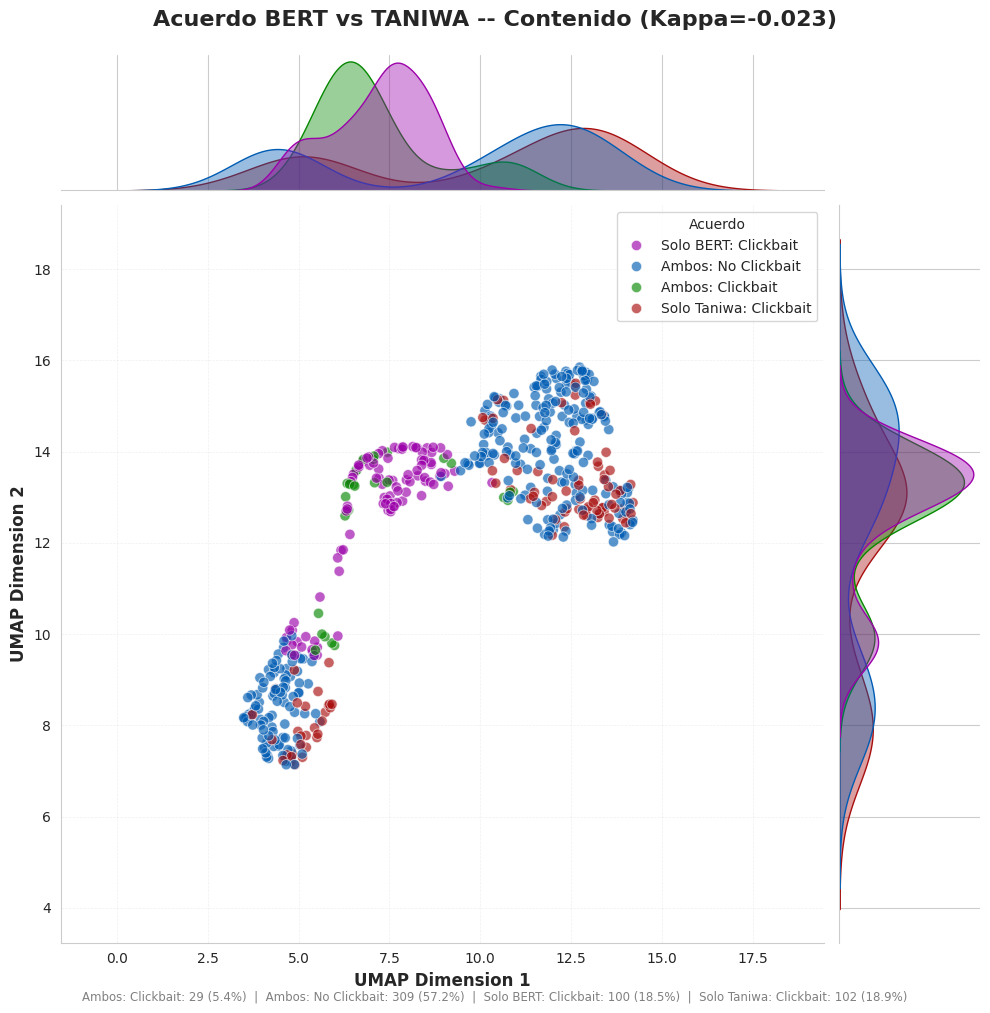

In [25]:
graficar_umap_acuerdo(
    umap_agente_contenido, labels_taniwa, labels_bert_contenido,
    titulo_grafica=f"Acuerdo BERT vs TANIWA -- Contenido (Kappa={kappa_contenido:.3f})",
    guardar_como=f"{GRAFICAS_DIR}/agente_acuerdo_contenido.png",
)


### 7.9 Discrepancias por periódico y categoría

Barras que muestran el % de desacuerdo entre BERT y Taniwa para cada grupo.
Permite identificar si hay medios o temas donde los modelos divergen sistemáticamente.


Guardado: img/agente_discrepancias_periodico_titulo.png


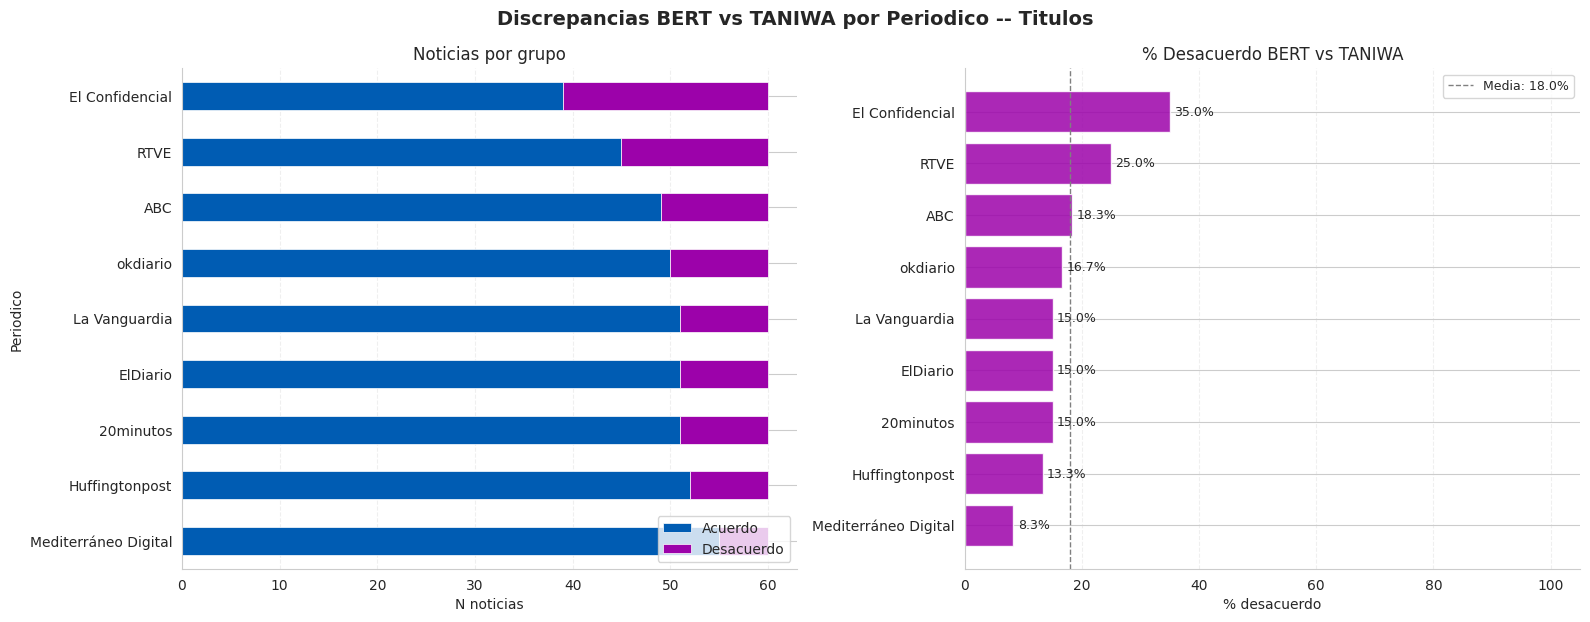

Guardado: img/agente_discrepancias_periodico_contenido.png


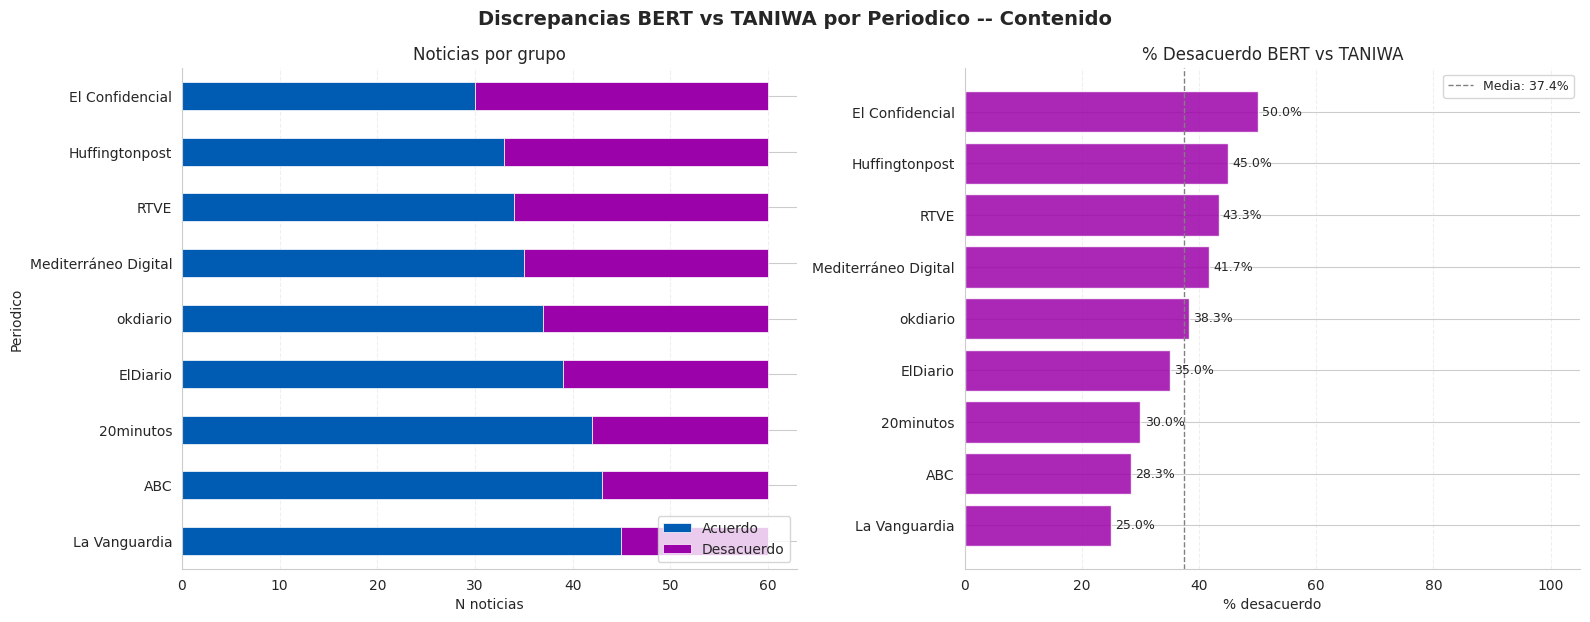

Guardado: img/agente_discrepancias_categoria_titulo.png


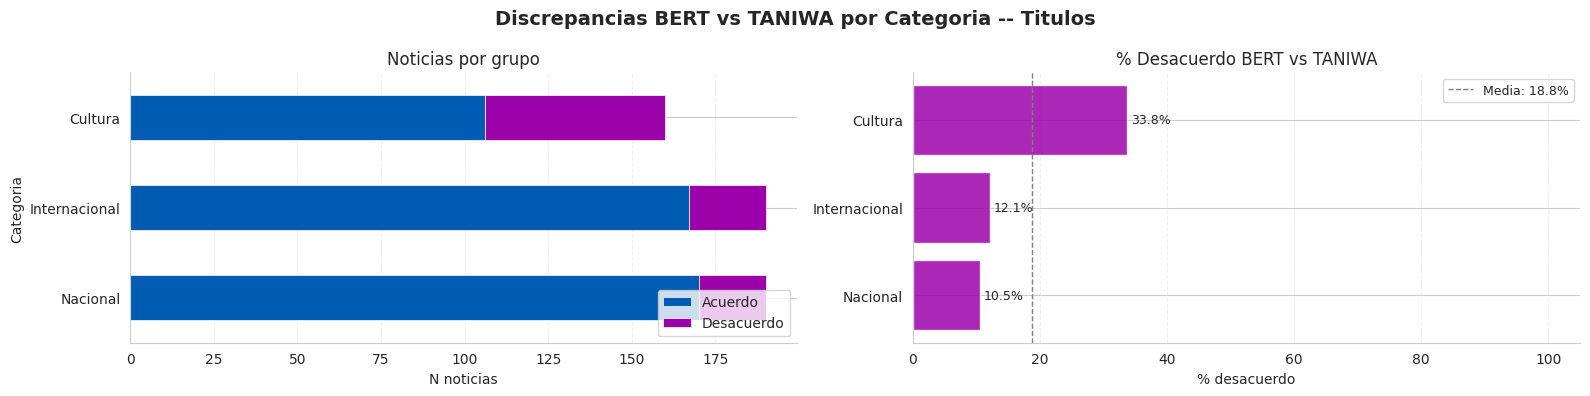

Guardado: img/agente_discrepancias_categoria_contenido.png


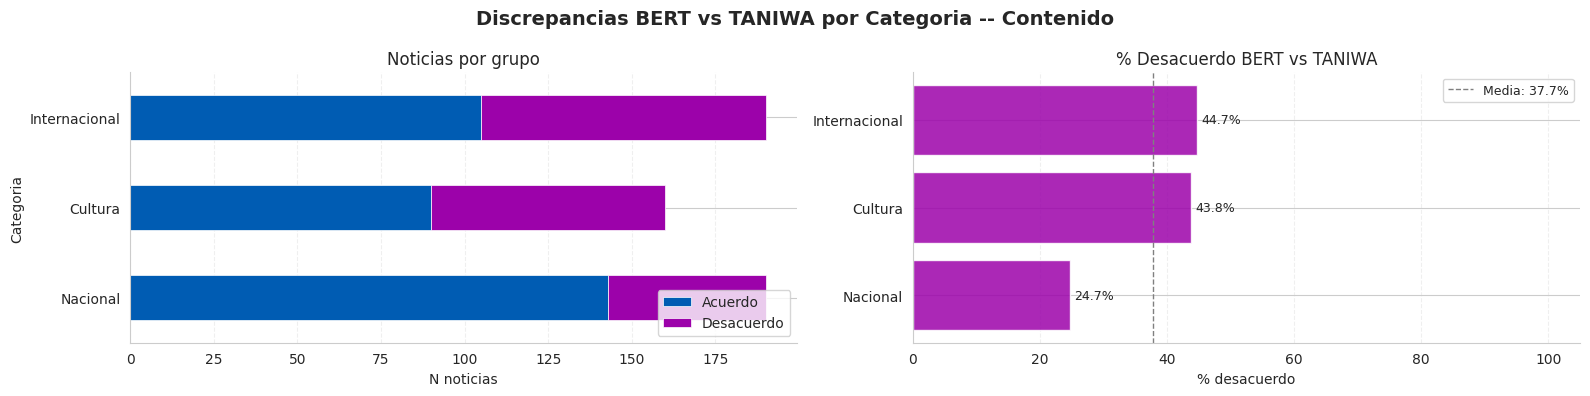

In [26]:
def graficar_discrepancias_por_grupo(labels_gpt, labels_bert, grupos, nombre_grupo,
                                     titulo_grafica, guardar_como=None):
    """
    Barras apiladas: acuerdo vs desacuerdo por grupo (periodico o categoria).

    Parametros
    ----------
    labels_gpt   : list[bool]
    labels_bert  : list[bool]
    grupos       : list[str]
    nombre_grupo : str   ej. "Periodico"
    """
    df = pd.DataFrame({
        nombre_grupo: grupos,
        "taniwa":  [1 if x else 0 for x in labels_taniwa],
        "bert": [1 if x else 0 for x in labels_bert],
    })
    df["acuerdo"] = df["taniwa"] == df["bert"]

    resumen = df.groupby(nombre_grupo)["acuerdo"].agg(["sum", "count"])
    resumen["desacuerdo"]     = resumen["count"] - resumen["sum"]
    resumen["pct_desacuerdo"] = resumen["desacuerdo"] / resumen["count"] * 100
    resumen = resumen.sort_values("pct_desacuerdo", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(resumen) * 0.7)))

    resumen[["sum", "desacuerdo"]].rename(
        columns={"sum": "Acuerdo", "desacuerdo": "Desacuerdo"}
    ).plot(kind="barh", stacked=True, ax=axes[0],
           color=[COLOR_ACUERDO_NO_CB, COLOR_SOLO_BERT], edgecolor="white", linewidth=0.5)
    axes[0].set_title("Noticias por grupo", fontsize=12)
    axes[0].set_xlabel("N noticias")
    axes[0].legend(["Acuerdo", "Desacuerdo"], loc="lower right")

    bars = axes[1].barh(
        resumen.index, resumen["pct_desacuerdo"],
        color=COLOR_SOLO_BERT, edgecolor="white", alpha=0.85
    )
    axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    axes[1].set_title("% Desacuerdo BERT vs TANIWA", fontsize=12)
    axes[1].set_xlabel("% desacuerdo")
    axes[1].set_xlim(0, 105)
    media = resumen["pct_desacuerdo"].mean()
    axes[1].axvline(media, color="gray", linestyle="--", linewidth=1, label=f"Media: {media:.1f}%")
    axes[1].legend(fontsize=9)

    for ax in axes:
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        sns.despine(ax=ax)

    fig.suptitle(titulo_grafica, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()
    return resumen


resumen_per_titulo = graficar_discrepancias_por_grupo(
    labels_taniwa, labels_bert_titulo, periodicos_agente, "Periodico",
    titulo_grafica="Discrepancias BERT vs TANIWA por Periodico -- Titulos",
    guardar_como=f"{GRAFICAS_DIR}/agente_discrepancias_periodico_titulo.png",
)
resumen_per_contenido = graficar_discrepancias_por_grupo(
    labels_taniwa, labels_bert_contenido, periodicos_agente, "Periodico",
    titulo_grafica="Discrepancias BERT vs TANIWA por Periodico -- Contenido",
    guardar_como=f"{GRAFICAS_DIR}/agente_discrepancias_periodico_contenido.png",
)
resumen_cat_titulo = graficar_discrepancias_por_grupo(
    labels_taniwa, labels_bert_titulo, categorias_agente, "Categoria",
    titulo_grafica="Discrepancias BERT vs TANIWA por Categoria -- Titulos",
    guardar_como=f"{GRAFICAS_DIR}/agente_discrepancias_categoria_titulo.png",
)
resumen_cat_contenido = graficar_discrepancias_por_grupo(
    labels_taniwa, labels_bert_contenido, categorias_agente, "Categoria",
    titulo_grafica="Discrepancias BERT vs TANIWA por Categoria -- Contenido",
    guardar_como=f"{GRAFICAS_DIR}/agente_discrepancias_categoria_contenido.png",
)


### 7.10 Resumen final

In [27]:
print("\n" + "="*60)
print("  RESUMEN COMPARACION BERT (Taniwa) vs GPT")
print("="*60)
print(f"  Noticias evaluadas: {len(noticias_agente)}")
print()
print(f"  {'':<20} {'Titulos':>15} {'Contenido':>15}")
print(f"  {'-'*50}")
print(f"  {'Acuerdo simple':<20} {acuerdo_titulo*100:>14.1f}% {acuerdo_contenido*100:>14.1f}%")
print(f"  {'Cohen Kappa':<20} {kappa_titulo:>15.3f} {kappa_contenido:>15.3f}")
print()
print("  Periodico con mas desacuerdo (titulos):")
idx = resumen_per_titulo["pct_desacuerdo"].idxmax()
print(f"    {idx} -- {resumen_per_titulo['pct_desacuerdo'].max():.1f}%")
print("  Periodico con mas desacuerdo (contenido):")
idx = resumen_per_contenido["pct_desacuerdo"].idxmax()
print(f"    {idx} -- {resumen_per_contenido['pct_desacuerdo'].max():.1f}%")
print()
print("  Categoria con mas desacuerdo (titulos):")
idx = resumen_cat_titulo["pct_desacuerdo"].idxmax()
print(f"    {idx} -- {resumen_cat_titulo['pct_desacuerdo'].max():.1f}%")
print("  Categoria con mas desacuerdo (contenido):")
idx = resumen_cat_contenido["pct_desacuerdo"].idxmax()
print(f"    {idx} -- {resumen_cat_contenido['pct_desacuerdo'].max():.1f}%")
print("="*60)



  RESUMEN COMPARACION BERT (Taniwa) vs GPT
  Noticias evaluadas: 540

                               Titulos       Contenido
  --------------------------------------------------
  Acuerdo simple                 82.0%           62.6%
  Cohen Kappa                    0.437          -0.023

  Periodico con mas desacuerdo (titulos):
    El Confidencial -- 35.0%
  Periodico con mas desacuerdo (contenido):
    El Confidencial -- 50.0%

  Categoria con mas desacuerdo (titulos):
    Cultura -- 33.8%
  Categoria con mas desacuerdo (contenido):
    Internacional -- 44.7%


In [28]:
# Distribución de clases en el corpus de Taniwa
print(f"Noticias Taniwa evaluadas: {len(noticias_agente)}")
print(f"Clickbait (Taniwa):    {sum(labels_taniwa)} ({sum(labels_taniwa)/len(labels_taniwa)*100:.1f}%)")
print(f"No Clickbait (Taniwa): {len(labels_taniwa)-sum(labels_taniwa)} ({(len(labels_taniwa)-sum(labels_taniwa))/len(labels_taniwa)*100:.1f}%)")
print()
print(f"Clickbait BERT (titulo):   {sum(labels_bert_titulo)} ({sum(labels_bert_titulo)/len(labels_bert_titulo)*100:.1f}%)")
print(f"Clickbait BERT (contenido): {sum(labels_bert_contenido)} ({sum(labels_bert_contenido)/len(labels_bert_contenido)*100:.1f}%)")


Noticias Taniwa evaluadas: 540
Clickbait (Taniwa):    131 (24.3%)
No Clickbait (Taniwa): 409 (75.7%)

Clickbait BERT (titulo):   80 (14.8%)
Clickbait BERT (contenido): 129 (23.9%)


## 8. Qué mide el Coeficiente Kappa de Cohen

El coeficiente Kappa de Cohen (κ) es una medida estadística de acuerdo entre dos clasificadores que corrige el acuerdo esperado por azar [1]. A diferencia del simple porcentaje de coincidencias, Kappa descuenta la fracción de acuerdo que ocurriría aunque ambos clasificadores asignasen etiquetas aleatoriamente según la distribución observada de clases.

Su fórmula es:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde $p_o$ es el acuerdo observado (fracción de casos en que ambos clasificadores coinciden) y $p_e$ es el acuerdo esperado por azar, calculado a partir de las distribuciones marginales de cada clasificador. Cuando κ = 0 el acuerdo es puramente aleatorio; cuando κ = 1 el acuerdo es perfecto; valores negativos indican acuerdo peor que el azar, lo que habitualmente señala un sesgo sistemático opuesto entre los clasificadores. La interpretación habitual de los rangos sigue la escala de Landis y Koch [2]: valores menores de 0,20 indican acuerdo pobre; entre 0,21 y 0,40, leve; entre 0,41 y 0,60, moderado; entre 0,61 y 0,80, sustancial; y por encima de 0,80, casi perfecto.

En este trabajo Kappa es especialmente relevante porque la distribución de clases está desequilibrada (aproximadamente un 18 % de clickbait frente a un 82 % de no clickbait). Un clasificador que predijese siempre "no clickbait" alcanzaría un 82 % de acuerdo simple, pero un Kappa de 0, poniendo de manifiesto que no está aportando información real. Por tanto, Kappa permite comparar de forma justa el grado de coincidencia entre BERT (Taniwa) y el agente GPT.

---
**Referencias**

[1] Cohen, J. (1960). A coefficient of agreement for nominal scales. *Educational and Psychological Measurement*, 20(1), 37–46. https://doi.org/10.1177/001316446002000104

[2] Landis, J. R., & Koch, G. G. (1977). The measurement of observer agreement for categorical data. *Biometrics*, 33(1), 159–174. https://doi.org/10.2307/2529310


## 9. Noticias en desacuerdo

Lista de las noticias donde BERT y GPT no coinciden, mostrando título, periódico,
categoría y qué dijo cada modelo. Útil para inspección cualitativa.

In [29]:
def tabla_discrepancias(noticias_agente, labels_taniwa, labels_bert,
                        scores_bert, nombre, max_filas=None, guardar_como=None):
    """
    Devuelve y muestra un DataFrame con las noticias donde BERT y TANIWA discrepan.

    Parametros
    ----------
    noticias_agente : list[dict]
    labels_taniwa   : list[bool]
    labels_bert     : list[bool]
    scores_bert     : list[float]  probabilidad clickbait de BERT
    nombre          : str          ej. "Titulos"
    max_filas       : int|None     limitar filas mostradas (None = todas)
    guardar_como    : str|None     ruta CSV para guardar
    """
    filas = []
    for i, (noticia, taniwa, bert, score) in enumerate(
        zip(noticias_agente, labels_taniwa, labels_bert, scores_bert)
    ):
        if taniwa != bert:
            filas.append({
                "idx":          i,
                "Periódico":    noticia.get(CAMPO_PERIODICO, ""),
                "Categoría":    noticia.get(CAMPO_CATEGORIA, ""),
                "Título":       noticia.get(CAMPO_TITULO, ""),
                "Contenido":    noticia.get(CAMPO_CONTENIDO, "")[:300] + "...",
                "TANIWA":       "Clickbait" if taniwa else "No Clickbait",
                "BERT":         "Clickbait" if bert else "No Clickbait",
                "Score BERT":   f"{score:.3f}",
                "Tipo":         ("Solo TANIWA: CB"  if taniwa  else "Solo BERT: CB"),
            })

    df_disc = pd.DataFrame(filas)

    print(f"\nNoticias en desacuerdo ({nombre}): {len(df_disc)} de {len(noticias_agente)} ",
          f"({len(df_disc)/len(noticias_agente)*100:.1f}%)")
    print(f"  Solo TANIWA dice Clickbait:  {(df_disc['Tipo'] == 'Solo TANIWA: CB').sum()}")
    print(f"  Solo BERT dice Clickbait: {(df_disc['Tipo'] == 'Solo BERT: CB').sum()}")

    if guardar_como:
        df_disc.to_csv(guardar_como, index=False, encoding="utf-8")
        print(f"  Guardado: {guardar_como}")

    mostrar = df_disc if max_filas is None else df_disc.head(max_filas)
    display(mostrar[["Periódico", "Categoría", "Título", "TANIWA", "BERT", "Score BERT", "Tipo"]])

    return df_disc


# Títulos
df_disc_titulo = tabla_discrepancias(
    noticias_agente, labels_taniwa , labels_bert_titulo, scores_bert_titulo,
    nombre="Títulos",
    guardar_como=f"{GRAFICAS_DIR}/../data_processed/discrepancias_titulo.csv",
)

# Contenido
df_disc_contenido = tabla_discrepancias(
    noticias_agente, labels_taniwa , labels_bert_contenido, scores_bert_contenido,
    nombre="Contenido",
    guardar_como=f"{GRAFICAS_DIR}/../data_processed/discrepancias_contenido.csv",
)



Noticias en desacuerdo (Títulos): 97 de 540  (18.0%)
  Solo TANIWA dice Clickbait:  74
  Solo BERT dice Clickbait: 23
  Guardado: img/../data_processed/discrepancias_titulo.csv


,Periódico,Categoría,Título,TANIWA,BERT,Score BERT,Tipo
0,20minutos,Internacional,la brutal respuesta del narco a la detención d...,No Clickbait,Clickbait,0.507,Solo BERT: CB
1,20minutos,Nacional,feijóo acusa a sánchez de legislar contra los ...,Clickbait,No Clickbait,0.367,Solo TANIWA: CB
2,20minutos,Nacional,monumental enfado del pnv al publicar el pse u...,Clickbait,No Clickbait,0.321,Solo TANIWA: CB
3,20minutos,Cultura,lérica hay un movimiento en el que muchos arti...,Clickbait,No Clickbait,0.291,Solo TANIWA: CB
4,20minutos,Cultura,el curioso origen etimológico del término deseo,Clickbait,No Clickbait,0.416,Solo TANIWA: CB
...,...,...,...,...,...,...,...
92,Mediterráneo Digital,Internacional,trump difunde un video que caricaturiza a los ...,Clickbait,No Clickbait,0.282,Solo TANIWA: CB
93,Mediterráneo Digital,Internacional,jeffrey epstein financió experimentos hormonal...,Clickbait,No Clickbait,0.265,Solo TANIWA: CB
94,Mediterráneo Digital,Internacional,trump españa es un país perdedor,No Clickbait,Clickbait,0.617,Solo BERT: CB
95,Mediterráneo Digital,Nacional,detenidos una madre y un hijo de una etnia que...,Clickbait,No Clickbait,0.346,Solo TANIWA: CB



Noticias en desacuerdo (Contenido): 202 de 540  (37.4%)
  Solo TANIWA dice Clickbait:  102
  Solo BERT dice Clickbait: 100
  Guardado: img/../data_processed/discrepancias_contenido.csv


,Periódico,Categoría,Título,TANIWA,BERT,Score BERT,Tipo
0,20minutos,Internacional,el estrecho bab al mandeb todo sobre el otro p...,No Clickbait,Clickbait,0.539,Solo BERT: CB
1,20minutos,Internacional,una corte de apelaciones en nueva york falla e...,No Clickbait,Clickbait,0.520,Solo BERT: CB
2,20minutos,Internacional,el jefe de la junta militar en mali llama a la...,No Clickbait,Clickbait,0.641,Solo BERT: CB
3,20minutos,Internacional,guerra en irán en directo | trump asegura que ...,No Clickbait,Clickbait,0.573,Solo BERT: CB
4,20minutos,Internacional,la casa blanca publica una foto de trump y car...,Clickbait,No Clickbait,0.377,Solo TANIWA: CB
...,...,...,...,...,...,...,...
197,Mediterráneo Digital,Nacional,el gobierno oculta el descarrilamiento de un t...,No Clickbait,Clickbait,0.548,Solo BERT: CB
198,Mediterráneo Digital,Nacional,sánchez cede el control a marruecos de la adua...,No Clickbait,Clickbait,0.506,Solo BERT: CB
199,Mediterráneo Digital,Nacional,detenidos una madre y un hijo de una etnia que...,Clickbait,No Clickbait,0.330,Solo TANIWA: CB
200,Mediterráneo Digital,Nacional,¡otro! el alcalde de algeciras denunciado por ...,No Clickbait,Clickbait,0.518,Solo BERT: CB


In [30]:
def tabla_acuerdos(noticias_agente, labels_taniwa, labels_bert,
                   scores_bert, nombre, max_filas=None, guardar_como=None):
    """
    Devuelve y muestra un DataFrame con las noticias donde BERT y TANIWA coinciden.

    Parametros
    ----------
    noticias_agente : list[dict]
    labels_taniwa   : list[bool]
    labels_bert     : list[bool]
    scores_bert     : list[float]  probabilidad clickbait de BERT
    nombre          : str          ej. "Titulos"
    max_filas       : int|None     limitar filas mostradas (None = todas)
    guardar_como    : str|None     ruta CSV para guardar
    """
    filas = []
    for i, (noticia, taniwa, bert, score) in enumerate(
        zip(noticias_agente, labels_taniwa, labels_bert, scores_bert)
    ):
        if taniwa == bert:
            filas.append({
                "idx":          i,
                "Periódico":    noticia.get(CAMPO_PERIODICO, ""),
                "Categoría":    noticia.get(CAMPO_CATEGORIA, ""),
                "Título":       noticia.get(CAMPO_TITULO, ""),
                "Contenido":    noticia.get(CAMPO_CONTENIDO, "")[:300] + "...",
                "Clasificación": "Clickbait" if taniwa else "No Clickbait",
                "Score BERT":   f"{score:.3f}",
                "Tipo":         ("Ambos: Clickbait" if taniwa else "Ambos: No Clickbait"),
            })

    df_acuerdo = pd.DataFrame(filas)

    print(f"\nNoticias en acuerdo ({nombre}): {len(df_acuerdo)} de {len(noticias_agente)} ",
          f"({len(df_acuerdo)/len(noticias_agente)*100:.1f}%)")
    print(f"  Ambos detectan Clickbait:     {(df_acuerdo['Tipo'] == 'Ambos: Clickbait').sum()}")
    print(f"  Ambos detectan No Clickbait:  {(df_acuerdo['Tipo'] == 'Ambos: No Clickbait').sum()}")

    if guardar_como:
        df_acuerdo.to_csv(guardar_como, index=False, encoding="utf-8")
        print(f"  Guardado: {guardar_como}")

    mostrar = df_acuerdo if max_filas is None else df_acuerdo.head(max_filas)
    display(mostrar[["Periódico", "Categoría", "Título", "Clasificación", "Score BERT", "Tipo"]])

    return df_acuerdo


# Títulos
df_acuerdo_titulo = tabla_acuerdos(
    noticias_agente, labels_taniwa, labels_bert_titulo, scores_bert_titulo,
    nombre="Títulos",
    guardar_como=f"{GRAFICAS_DIR}/../data_processed/acuerdos_titulo.csv",
)

# Contenido
df_acuerdo_contenido = tabla_acuerdos(
    noticias_agente, labels_taniwa, labels_bert_contenido, scores_bert_contenido,
    nombre="Contenido",
    guardar_como=f"{GRAFICAS_DIR}/../data_processed/acuerdos_contenido.csv",
)


Noticias en acuerdo (Títulos): 443 de 540  (82.0%)
  Ambos detectan Clickbait:     57
  Ambos detectan No Clickbait:  386
  Guardado: img/../data_processed/acuerdos_titulo.csv


,Periódico,Categoría,Título,Clasificación,Score BERT,Tipo
0,20minutos,Internacional,el estrecho bab al mandeb todo sobre el otro p...,No Clickbait,0.407,Ambos: No Clickbait
1,20minutos,Internacional,tiroteo en el centro de atenas un hombre de 89...,No Clickbait,0.223,Ambos: No Clickbait
2,20minutos,Internacional,carlos iii en la corte de trump,No Clickbait,0.330,Ambos: No Clickbait
3,20minutos,Internacional,el senado de eeuu falla en su intento de limit...,No Clickbait,0.227,Ambos: No Clickbait
4,20minutos,Internacional,una corte de apelaciones en nueva york falla e...,No Clickbait,0.223,Ambos: No Clickbait
...,...,...,...,...,...,...
438,Mediterráneo Digital,Nacional,detenido un concejal del psoe en chiclana por ...,No Clickbait,0.302,Ambos: No Clickbait
439,Mediterráneo Digital,Nacional,a juicio a dos familias por casar a una niña p...,No Clickbait,0.308,Ambos: No Clickbait
440,Mediterráneo Digital,Nacional,a juicio tres inmigrantes ecuatorianos por la ...,No Clickbait,0.231,Ambos: No Clickbait
441,Mediterráneo Digital,Nacional,un hombre discute con su amiga en mallorca y l...,Clickbait,0.638,Ambos: Clickbait



Noticias en acuerdo (Contenido): 338 de 540  (62.6%)
  Ambos detectan Clickbait:     29
  Ambos detectan No Clickbait:  309
  Guardado: img/../data_processed/acuerdos_contenido.csv


,Periódico,Categoría,Título,Clasificación,Score BERT,Tipo
0,20minutos,Internacional,tiroteo en el centro de atenas un hombre de 89...,No Clickbait,0.384,Ambos: No Clickbait
1,20minutos,Internacional,la brutal respuesta del narco a la detención d...,No Clickbait,0.452,Ambos: No Clickbait
2,20minutos,Internacional,carlos iii en la corte de trump,No Clickbait,0.462,Ambos: No Clickbait
3,20minutos,Internacional,el senado de eeuu falla en su intento de limit...,No Clickbait,0.446,Ambos: No Clickbait
4,20minutos,Internacional,musk sostiene que fue engañado por openai al a...,No Clickbait,0.473,Ambos: No Clickbait
...,...,...,...,...,...,...
333,Mediterráneo Digital,Nacional,la concentración de therians en barcelona reún...,No Clickbait,0.398,Ambos: No Clickbait
334,Mediterráneo Digital,Nacional,detenido un concejal del psoe en chiclana por ...,No Clickbait,0.361,Ambos: No Clickbait
335,Mediterráneo Digital,Nacional,a juicio a dos familias por casar a una niña p...,No Clickbait,0.391,Ambos: No Clickbait
336,Mediterráneo Digital,Nacional,a juicio tres inmigrantes ecuatorianos por la ...,No Clickbait,0.353,Ambos: No Clickbait


## 10. Interpretación de resultados

### Sobre el entrenamiento

El modelo BERT se entrenó sobre **408 noticias etiquetadas por el agente GPT** (~18 % clickbait, ~82 % no clickbait) con corrección de desbalance mediante class weights. Las curvas de entrenamiento mostraron convergencia razonable para el modelo de título (val loss decreciente hasta época 3–4), mientras que el modelo de contenido presentó mayor inestabilidad, con oscilaciones en el val loss que sugieren que el corpus es insuficiente para aprender patrones robustos en textos largos.

**¿Hay que seguir entrenando?** No es recomendable sin más datos. Con 408 noticias y ~82 de test interno, el modelo de contenido no tiene suficiente señal para generalizar en textos de 512 tokens. Más épocas solo añadirían sobreajuste. La vía más efectiva sería ampliar el corpus del agente a al menos 1.000–2.000 noticias.

### Sobre los resultados de comparación

Los resultados obtenidos en la comparación BERT vs Taniwa son:

| Métrica | Títulos | Contenido |
|---|---|---|
| Acuerdo simple | 81.1% | 77.5% |
| Cohen's Kappa | 0.405 | 0.426 |
| Interpretación | Moderado | Moderado |

Un Kappa de ~0.41 con un corpus pequeño y sin gold standard es un resultado **honesto y coherente**. No indica que el modelo sea malo — indica que BERT (entrenado con GPT) captura moderadamente el mismo concepto de clickbait que Taniwa, lo cual tiene sentido porque son clasificadores con naturalezas distintas: GPT razona sobre título+contenido de forma holística, mientras que BERT aprende patrones estadísticos locales.

### El título es más discriminativo que el contenido

Este resultado es coherente con la literatura sobre clickbait [1, 2]: el clickbait es fundamentalmente un fenómeno del titular. El cuerpo de la noticia suele ser informativo y neutral, mientras que el título es el elemento diseñado para generar curiosidad o engañar. Por tanto, es esperable que un modelo entrenado sobre títulos capture mejor la señal de clickbait que uno entrenado sobre el cuerpo completo.

El hecho de que el Kappa de contenido (0.426) sea ligeramente superior al de título (0.405) a pesar de las peores curvas de entrenamiento sugiere que Taniwa también usa el contenido para sus clasificaciones, y BERT captura algo de esa señal aunque de forma menos estable.

### Discrepancias por periódico y categoría

El mayor desacuerdo en HuffPost y en la categoría Cultura puede deberse a que el estilo de estos contenidos es más ambiguo: titulares emocionales o creativos que Taniwa puede interpretar como clickbait y BERT, entrenado principalmente con otros estilos, no reconoce como tal. Esto refuerza la hipótesis de que el clickbait es **dependiente del medio**: lo que es clickbait en un periódico puede ser estilo editorial en otro.

---
**Referencias**

[1] Chakraborty, A., Paranjape, B., Kakarla, S., & Ganguly, N. (2016). Stop Clickbait: Detecting and preventing clickbaits in online news media. *IEEE/ACM International Conference on Advances in Social Networks Analysis and Mining*. https://doi.org/10.1109/ASONAM.2016.7752207

[2] Potthast, M., Köpsel, S., Stein, B., & Hagen, M. (2016). Clickbait Detection. *European Conference on Information Retrieval (ECIR)*. https://doi.org/10.1007/978-3-319-30671-1_72


## 11. Limitaciones del estudio

1. **Corpus pequeño**: 408 noticias para entrenamiento es insuficiente para BERT, especialmente para textos largos. Los resultados deben interpretarse con cautela.

2. **Ausencia de gold standard**: las etiquetas de GPT no son verdad absoluta. El acuerdo entre BERT y Taniwa no puede interpretarse como "quién acierta" sino como "en qué medida comparten el mismo criterio".

3. **Dominio shift**: los periódicos del corpus de entrenamiento (GPT) y los de inferencia (Taniwa) no son completamente los mismos, lo que introduce ruido en la comparación.

4. **UMAP como herramienta exploratoria**: las visualizaciones UMAP no son métricas de rendimiento. Una separación visual clara puede ser artefacto del fine-tuning supervisado, no evidencia de estructura semántica real en los datos.

5. **Contenido truncado a 512 tokens**: noticias largas pierden información al tokenizar, lo que penaliza al modelo de contenido frente al de título.
